# MazeMind AI: Smart Maze Solver using Reinforcement Learning


In [1]:
# Install necessary libraries (if not already installed)
# !pip install numpy matplotlib tensorflow

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from collections import deque
import random

In [2]:
class Maze:
    def __init__(self, maze_map, start, goal):
        self.maze_map = np.array(maze_map) # The 2D grid representing the maze
        self.start = tuple(start)          # Starting position (row, col)
        self.goal = tuple(goal)            # Goal position (row, col)
        self.agent_pos = self.start       # Agent's current position
        self.rows, self.cols = self.maze_map.shape # Dimensions of the maze

        # Define actions: 0: Up, 1: Down, 2: Left, 3: Right
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        self.action_names = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}

        # Reward values
        self.reward_goal = 100
        self.reward_wall = -10
        self.reward_step = -1 # Penalty for each step to encourage shorter paths

    def reset(self):
        """Resets the agent's position to the start and returns the initial state."""
        self.agent_pos = self.start
        return self.agent_pos

    def step(self, action):
        """Takes an action and returns the new state, reward, and whether the episode is done."""
        current_row, current_col = self.agent_pos
        dr, dc = self.actions[action]
        new_row, new_col = current_row + dr, current_col + dc

        reward = self.reward_step # Default reward for taking a step
        done = False

        # Check if new position is out of bounds or a wall
        if not (0 <= new_row < self.rows and 0 <= new_col < self.cols) or \
           self.maze_map[new_row, new_col] == 1: # 1 represents a wall
            # Invalid move (hit wall or out of bounds)
            reward = self.reward_wall
            new_pos = self.agent_pos # Agent stays in the current position
        else:
            # Valid move
            new_pos = (new_row, new_col)
            self.agent_pos = new_pos

            # Check if agent reached the goal
            if new_pos == self.goal:
                reward = self.reward_goal
                done = True

        return new_pos, reward, done

    def render(self, path=None):
        """Visualizes the maze with the agent and optionally the path."""
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(self.maze_map, cmap=plt.cm.binary, origin='upper')

        # Draw grid lines
        ax.set_xticks(np.arange(-0.5, self.cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.rows, 1), minor=True)
        ax.grid(which="minor", color="gray", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)

        # Mark start and goal
        ax.plot(self.start[1], self.start[0], "bs", markersize=15, label="Start") # Blue Square
        ax.plot(self.goal[1], self.goal[0], "ro", markersize=15, label="Goal")   # Red Circle

        # Mark agent's current position
        ax.plot(self.agent_pos[1], self.agent_pos[0], "y^", markersize=15, label="Agent") # Yellow Triangle

        # Plot the optimal path if provided
        if path:
            path_rows = [p[0] for p in path]
            path_cols = [p[1] for p in path]
            ax.plot(path_cols, path_rows, 'g--', linewidth=2, label="Optimal Path")

        ax.set_title("Maze Environment")
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.legend()
        plt.show()

    def get_state_space_size(self):
        """Returns the total number of possible states in the maze."""
        return self.rows * self.cols

    def get_action_space_size(self):
        """Returns the total number of possible actions."""
        return len(self.actions)


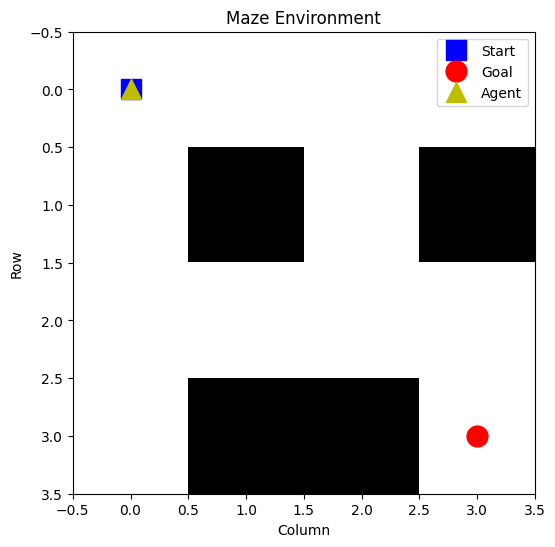

In [3]:
# Define the maze map (0: path, 1: wall)
# S: Start, G: Goal
# Example maze:
# S 0 0 0
# 0 1 0 1
# 0 0 0 0
# 0 1 1 G
maze_map = [
    [0, 0, 0, 0],
    [0, 1, 0, 1],
    [0, 0, 0, 0],
    [0, 1, 1, 0]
]

start_pos = (0, 0) # Start at (row 0, col 0)
goal_pos = (3, 3)  # Goal at (row 3, col 3)

# Create a Maze instance
maze_env = Maze(maze_map, start_pos, goal_pos)

# Visualize the initial maze state
maze_env.render()


In [4]:
def create_q_model(state_space_size, action_space_size):
    """Creates a simple feed-forward neural network for Q-value approximation."""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(state_space_size,)), # Input layer takes the flattened state
        tf.keras.layers.Dense(64, activation='relu'),    # Hidden layer 1
        tf.keras.layers.Dense(64, activation='relu'),    # Hidden layer 2
        tf.keras.layers.Dense(action_space_size, activation='linear') # Output layer: Q-values for each action
    ])
    return model

In [5]:
class DQNAgent:
    def __init__(self, state_space_size, action_space_size):
        self.state_space_size = state_space_size
        self.action_space_size = action_space_size

        # Hyperparameters
        self.learning_rate = 0.001       # Learning rate for the neural network
        self.gamma = 0.95                # Discount factor for future rewards
        self.epsilon = 1.0               # Exploration-exploitation trade-off parameter (starts high for exploration)
        self.epsilon_decay = 0.995       # Rate at which epsilon decays
        self.epsilon_min = 0.01          # Minimum value for epsilon
        self.batch_size = 32             # Number of experiences to sample from replay buffer
        self.target_update_frequency = 10 # How often to update the target network

        # Experience Replay Buffer
        self.memory = deque(maxlen=2000) # Stores experiences (state, action, reward, next_state, done)

        # Build Q-networks
        self.q_network = create_q_model(state_space_size, action_space_size)
        self.target_q_network = create_q_model(state_space_size, action_space_size)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)

        # Compile the Q-network
        self.q_network.compile(optimizer=self.optimizer, loss='mse')

        # Initialize target network weights to be the same as Q-network
        self.update_target_network()

    def update_target_network(self):
        """Copies weights from the Q-network to the target Q-network."""
        self.target_q_network.set_weights(self.q_network.get_weights())

    def remember(self, state, action, reward, next_state, done):
        """Stores an experience in the replay buffer."""
        self.memory.append((state, action, reward, next_state, done))

    def _to_one_hot(self, state_idx):
        """Converts a state index to a one-hot encoded vector."""
        one_hot = np.zeros(self.state_space_size)
        one_hot[state_idx] = 1
        return one_hot

    def get_action(self, state_idx):
        """Selects an action using an epsilon-greedy policy."""
        if np.random.rand() <= self.epsilon: # Explore: choose a random action
            return np.random.randint(self.action_space_size)
        else: # Exploit: choose the action with the highest Q-value
            # Convert state_idx to one-hot for network input
            state_one_hot = self._to_one_hot(state_idx)
            state_reshaped = state_one_hot.reshape(1, -1) # Reshape for batch prediction
            q_values = self.q_network.predict(state_reshaped, verbose=0)
            return np.argmax(q_values[0])

    def train(self):
        """Trains the Q-network using a batch of experiences from the replay buffer."""
        if len(self.memory) < self.batch_size:
            return # Not enough experiences to train

        # Sample a random batch from memory
        minibatch = random.sample(self.memory, self.batch_size)

        # Prepare states, actions, rewards, next_states, and dones for batch processing
        # Convert state_idx to one-hot encoded vectors
        states_batch = np.array([self._to_one_hot(experience[0]) for experience in minibatch])
        actions_batch = np.array([experience[1] for experience in minibatch])
        rewards_batch = np.array([experience[2] for experience in minibatch])
        next_states_batch = np.array([self._to_one_hot(experience[3]) for experience in minibatch])
        dones_batch = np.array([experience[4] for experience in minibatch])

        # Predict Q-values for current states using the main Q-network
        current_q_values = self.q_network.predict(states_batch, verbose=0)

        # Predict Q-values for next states using the target Q-network
        # This is where the stability comes from - target network is fixed for a while
        next_q_values_target = self.target_q_network.predict(next_states_batch, verbose=0)

        # Create target Q-values for training
        target_q_values = np.copy(current_q_values)
        for i in range(self.batch_size):
            if dones_batch[i]:
                # If the episode is done, the target Q-value is just the reward
                target_q_values[i, actions_batch[i]] = rewards_batch[i]
            else:
                # Bellman equation: Q(s,a) = r + gamma * max_a' Q(s',a')
                target_q_values[i, actions_batch[i]] = rewards_batch[i] + self.gamma * np.max(next_q_values_target[i])

        # Train the main Q-network
        self.q_network.train_on_batch(states_batch, target_q_values)

        # Decay epsilon to reduce exploration over time
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


In [6]:
def train_dqn_agent(maze_env, agent, episodes):
    """Trains the DQN agent in the maze environment."""
    episode_rewards = []
    print(f"\nStarting DQN training for {episodes} episodes...")

    for e in range(episodes):
        state = maze_env.reset() # Reset maze for a new episode
        # Convert state tuple (row, col) to a single integer for the neural network input
        state_idx = state[0] * maze_env.cols + state[1]

        done = False
        total_reward = 0
        max_steps_per_episode = maze_env.rows * maze_env.cols * 2 # Prevent infinite loops
        steps = 0

        while not done and steps < max_steps_per_episode:
            action = agent.get_action(state_idx) # Agent chooses an action
            next_state, reward, done = maze_env.step(action) # Perform action in environment

            # Convert next_state tuple to integer index
            next_state_idx = next_state[0] * maze_env.cols + next_state[1]

            agent.remember(state_idx, action, reward, next_state_idx, done) # Store experience
            agent.train() # Train the agent

            state_idx = next_state_idx # Update current state
            total_reward += reward
            steps += 1

        episode_rewards.append(total_reward)

        # Update target network periodically
        if e % agent.target_update_frequency == 0:
            agent.update_target_network()

        # Print progress
        if (e + 1) % 10 == 0 or e == episodes - 1:
            avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else np.mean(episode_rewards)
            print(f"Episode {e+1}/{episodes}, Total Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.2f}, Avg Reward (last 10): {avg_reward:.2f}")

    print("DQN training finished.")
    return episode_rewards

# Instantiate the agent and start training
state_space_size = maze_env.get_state_space_size()
action_space_size = maze_env.get_action_space_size()

dqn_agent = DQNAgent(state_space_size, action_space_size)

# Define training parameters
num_episodes = 200 # You can increase this for better performance

# Train the agent
training_rewards = train_dqn_agent(maze_env, dqn_agent, num_episodes)



Starting DQN training for 200 episodes...
Episode 10/200, Total Reward: -86.00, Epsilon: 0.26, Avg Reward (last 10): -124.60
Episode 20/200, Total Reward: -32.00, Epsilon: 0.05, Avg Reward (last 10): -48.20
Episode 30/200, Total Reward: -32.00, Epsilon: 0.01, Avg Reward (last 10): -9.40
Episode 40/200, Total Reward: -32.00, Epsilon: 0.01, Avg Reward (last 10): 35.90
Episode 50/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (last 10): 81.30
Episode 60/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (last 10): 94.40
Episode 70/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (last 10): 10.80
Episode 80/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (last 10): 95.00
Episode 90/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (last 10): 84.00
Episode 100/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (last 10): 95.00
Episode 110/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (last 10): 94.80
Episode 120/200, Total Reward: 95.00, Epsilon: 0.01, Avg Reward (las

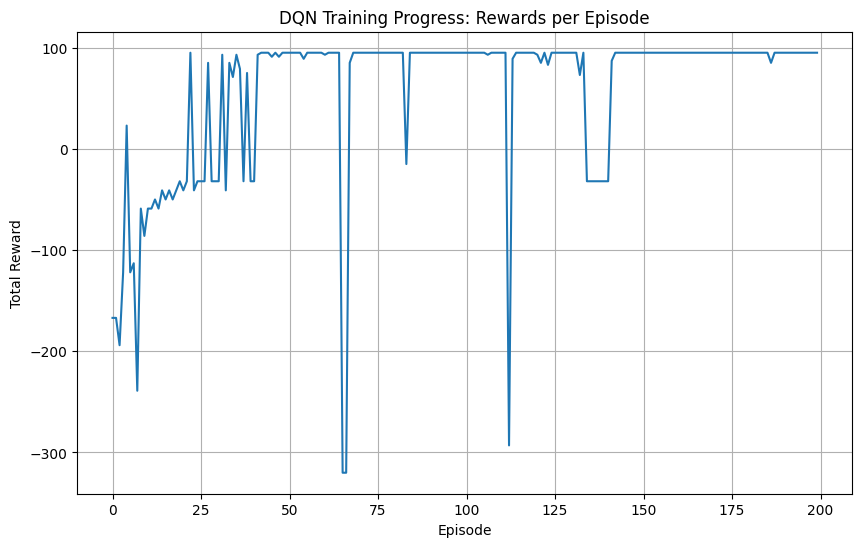

In [7]:
def plot_training_progress(episode_rewards):
    """Plots the rewards obtained per episode during training."""
    plt.figure(figsize=(10, 6))
    plt.plot(episode_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('DQN Training Progress: Rewards per Episode')
    plt.grid(True)
    plt.show()

plot_training_progress(training_rewards)



Running trained agent to find the optimal path...
Demonstration finished in 6 steps with total reward: 95.00


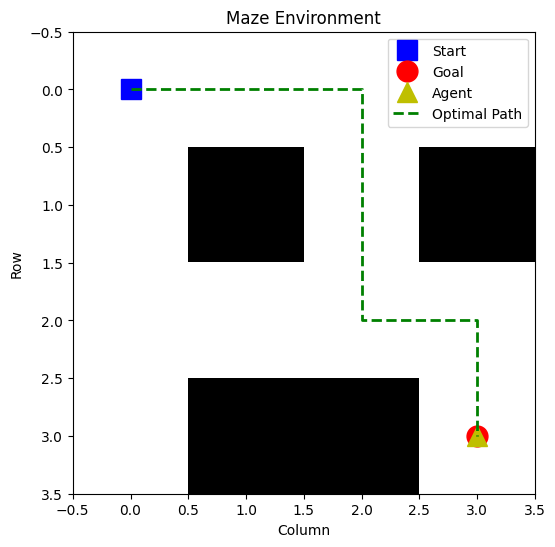

In [10]:
def run_trained_agent(maze_env, agent):
    """Runs the trained agent through the maze and records the path."""
    print("\nRunning trained agent to find the optimal path...")

    # Temporarily set epsilon to 0 for full exploitation (no exploration)
    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    state = maze_env.reset()
    state_idx = state[0] * maze_env.cols + state[1]
    path = [state]
    done = False
    total_reward = 0
    steps = 0
    max_steps_per_episode = maze_env.rows * maze_env.cols * 2 # Safety break

    while not done and steps < max_steps_per_episode:
        action = agent.get_action(state_idx)
        next_state, reward, done = maze_env.step(action)

        path.append(next_state)
        state_idx = next_state[0] * maze_env.cols + next_state[1]
        total_reward += reward
        steps += 1

    print(f"Demonstration finished in {steps} steps with total reward: {total_reward:.2f}")

    # Restore original epsilon
    agent.epsilon = original_epsilon

    return path, total_reward

# Run the trained agent
optimal_path, final_reward = run_trained_agent(maze_env, dqn_agent)

# Render the maze with the optimal path
maze_env.render(path=optimal_path)
